In [ ]:
from langchain_ollama import ChatOllama
llm = ChatOllama(base_url="http://localhost:11434",model="qwen3:0.6b-q4_K_M", temperature=0.7)
llm.invoke("What is the capital of France?")

In [ ]:
from app.agent.graph import ResearchAgent

agent = ResearchAgent()
agent._llm_router.invoke("What is the capital of France?")

c:\Users\afiniti\.conda\envs\BrieflyAI\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
c:\Users\afiniti\.conda\envs\BrieflyAI\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


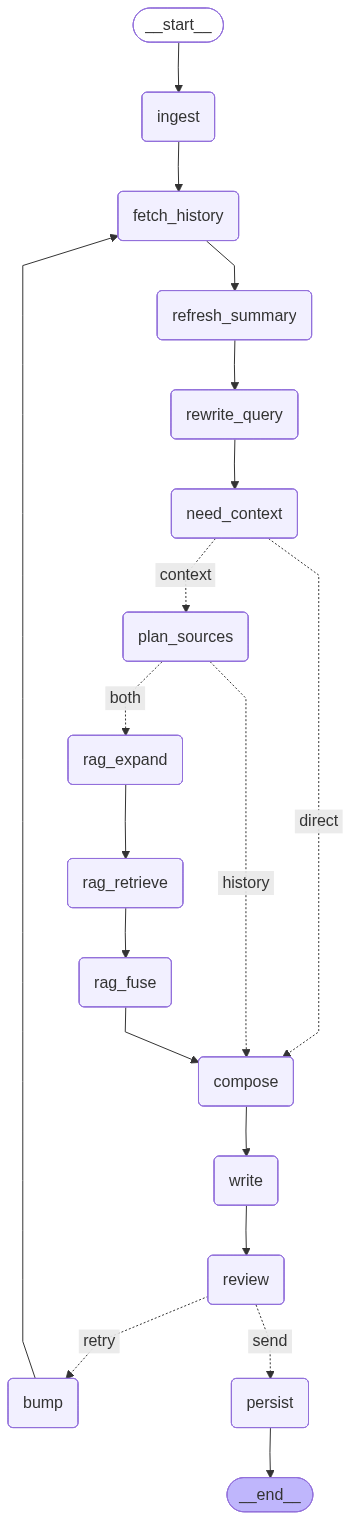

In [1]:
from app.agent.graph import ResearchAgent
from IPython.display import Image, display

# Initialize the agent
agent = ResearchAgent()

# Build the graph
state_graph = agent._build_graph()
chat_graph = state_graph.compile()
display(Image(chat_graph.get_graph().draw_mermaid_png()))

In [ ]:
import asyncio
import logging
import uuid
from logging.handlers import RotatingFileHandler
from pathlib import Path
from sqlalchemy import select
from app.agent.graph import ResearchAgent
from app.core.security import hash_password
from app.db.engine import AsyncSqlEngine, get_session
from app.db.models import AppUser, ChatThread
from app.settings import get_settings

# Run this single cell to smoke-test the LangGraph agent end-to-end.
# It will:
# 1) initialize DB engine
# 2) ensure a test user + chat thread exist
# 3) start the agent and stream one response
# 4) print project logs in notebook output + tail file logs

def configure_notebook_logging() -> Path:
    settings = get_settings()
    log_path = Path(settings.log_dir) / settings.log_file_name
    log_path.parent.mkdir(parents=True, exist_ok=True)

    # Stream logs to notebook output.
    logging.basicConfig(
        level=getattr(logging, settings.log_level.upper(), logging.INFO),
        format="%(levelname)s | %(name)s | %(message)s",
        force=True,
    )

    # Also write logs to file so tail output is meaningful.
    file_handler = RotatingFileHandler(
        log_path,
        maxBytes=settings.log_max_size_mb * 1024 * 1024,
        backupCount=settings.log_backup_count,
        encoding="utf-8",
    )
    file_handler.setLevel(getattr(logging, settings.log_level.upper(), logging.INFO))
    file_handler.setFormatter(
        logging.Formatter("%(asctime)s | %(levelname)s | %(name)s | %(message)s")
    )
    logging.getLogger().addHandler(file_handler)

    # Make sure key project loggers emit at configured level.
    for name in ("app", "app.agent", "app.db", "app.services", "alembic"):
        logging.getLogger(name).setLevel(getattr(logging, settings.log_level.upper(), logging.INFO))

    print(f"Logging enabled. Level={settings.log_level.upper()} file={log_path}")
    return log_path


def print_log_tail(log_path: Path, lines: int = 40) -> None:
    if not log_path.exists():
        print(f"Log file not found yet: {log_path}")
        return

    try:
        tail = log_path.read_text(encoding="utf-8", errors="replace").splitlines()[-lines:]
        print(f"\n=== LAST {min(lines, len(tail))} LOG LINES ({log_path}) ===")
        for line in tail:
            print(line)
    except Exception as exc:
        print(f"Unable to read log tail: {exc}")


async def run_agent_smoke_test(query: str = "Summarize one important trend in LLM retrieval research"):
    log_path = configure_notebook_logging()

    await AsyncSqlEngine.init_engine()
    await AsyncSqlEngine.init_readonly_engine()

    user_id = "notebook-test-user-1"
    chat_id = str(uuid.uuid4())

    async with get_session() as session:
        async with session.begin():
            user_exists = (
                await session.execute(
                    select(AppUser.user_id).where(AppUser.user_id == user_id)
                )
            ).scalar_one_or_none()
            if not user_exists:
                session.add(
                    AppUser(
                        user_id=user_id,
                        email="notebook-test-user-1@example.com",
                        hashed_password=hash_password("StrongPass123!"),
                    )
                )

            session.add(
                ChatThread(
                    chat_id=chat_id,
                    user_id=user_id,
                    title="Notebook Agent Smoke Test",
                    focused_paper_ids=["019d8a2e-fcef-7d19-a3ac-29d88f949832"],
                )
            )

    agent = ResearchAgent()
    await agent.startup()
    final_answer = ""

    try:
        async for event in agent.run_stream(
            user_id=user_id,
            chat_id=chat_id,
            query=query,
            thinking_mode="fast",
            llm_provider="groq",  # Set to "ollama" to test Ollama instead (requires Ollama running with qwen3:0.6b-fp16)
        ):
            update = event.get("update", {})
            print(f"seq={event.get('seq')} nodes={list(update.keys())}")

            for node_state in update.values():
                if isinstance(node_state, dict) and "draft" in node_state:
                    final_answer = node_state["draft"]
                    print(f"--- Draft Update ---\n{final_answer}\n--------------------")

        print("\n=== FINAL ANSWER ===")
        print(final_answer or "(No draft produced)")
    finally:
        await agent.shutdown()
        print_log_tail(log_path, lines=50)

await run_agent_smoke_test(query="tell me about Immune2V Paper in detail")